In [23]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated,Literal
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
import os

In [24]:
load_dotenv ()
llm = ChatGroq(
    groq_api_key=os.getenv("GROQ_API_KEY") ,
    model="llama-3.3-70b-versatile"
)

In [25]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage],add_messages]

In [26]:


def chat_node(state: ChatState):

    #take user query from state
    messages=state['messages']

    #send to llm
    response=llm.invoke(messages)

    #response store state
    return {'messages': [response]}

In [27]:
checkpointer=MemorySaver()
graph=StateGraph(ChatState)

graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

workflow=graph.compile(checkpointer=checkpointer)

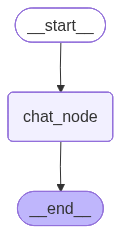

In [28]:
workflow

In [29]:
initial_state={
    'messages': [HumanMessage(content='what is langgraph')]
}
workflow.invoke(initial_state)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [30]:
thread_id='1'

while True:

    user_message=input('Type here:')

    print('user:',user_message)

    if user_message.strip().lower() in ['exit','quit','bye']:
        break

    config={'configurable':{'thread_id':thread_id}}

    response=workflow.invoke({'messages':[HumanMessage(content=user_message)]},config=config)

    print('AI:',response['messages'][-1].content)

user: hi ia m amisha
AI: Hello Amisha, it's nice to meet you. Is there something I can help you with or would you like to chat?
user: who am i
AI: You are Amisha, the person I'm chatting with. You introduced yourself to me at the beginning of our conversation. Would you like to tell me a bit more about yourself, or is there something specific you'd like to talk about?
user: quite
AI: It seems like you're being a bit mysterious, Amisha. "Quite" can be a bit of an enigmatic response. Would you like to elaborate on what you mean, or is it a secret for now?
user: quit


In [31]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi ia m amisha', additional_kwargs={}, response_metadata={}, id='4267e105-2900-4139-ae18-700b0ce156b9'), AIMessage(content="Hello Amisha, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 40, 'total_tokens': 67, 'completion_time': 0.056378248, 'prompt_time': 0.001787557, 'queue_time': 0.249431892, 'total_time': 0.058165805}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_4cfc2deea6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--1562e77d-4bfe-4379-8668-b85f9ee057d2-0', usage_metadata={'input_tokens': 40, 'output_tokens': 27, 'total_tokens': 67}), HumanMessage(content='who am i', additional_kwargs={}, response_metadata={}, id='6e1c2b4b-2dfc-4c49-9e1a-2d22add1ca47'), AIMessage(content="You are Amisha, the perso